In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score

from config import NN_TRAINING_PATH, NN_PREDICTIONS_PATH, NN_RESULTS_METRICS, NN_RESULTS_PREDICTIONS_WITH_ERRORS, NN_ERROR_BY_CVA, CALIBRATION_BY_DECILE, VALIDATION_PLOTS_PATH



In [2]:
training = pd.read_csv(NN_TRAINING_PATH)
predictions = pd.read_csv(NN_PREDICTIONS_PATH)

In [3]:
required_training_columns = {"epoch", "train_loss", "validation_loss"}

required_prediction_columns = {"True_CVA", "Predicted_CVA"}

missing_training = (required_training_columns - set(training.columns))

missing_predictions = (required_prediction_columns - set(predictions.columns))

if missing_training:
    raise ValueError(f"Missing training columns: {missing_training}")

if missing_predictions:
    raise ValueError(f"Missing prediction columns: {missing_predictions}")

#### Training diagnostic : We report how training went, including best epoch, error for best epoch, training and validation loss for that epoch etc

In [4]:
best_index = training["validation_loss"].idxmin()
best_row = training.loc[best_index]

best_epoch = int(best_row["epoch"])
best_validation_loss = best_row["validation_loss"]
train_loss_at_best = best_row["train_loss"]

training["generalisation_gap"] = (training["validation_loss"] - training["train_loss"])

print(f"Epochs completed: {len(training)}")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_validation_loss:.10f}")
print(f"Training loss at best epoch: {train_loss_at_best:.10f}")
print(f"Gap at best epoch: {best_validation_loss - train_loss_at_best:.10f}")

Epochs completed: 80
Best epoch: 70
Best validation loss: 0.0002429612
Training loss at best epoch: 0.0002516654
Gap at best epoch: -0.0000087042


#### Prediction diagnostics : We look at how the predictions compare to the true CVAs by reporting various metrics

In [5]:
y_true = predictions["True_CVA"].to_numpy()
y_pred = predictions["Predicted_CVA"].to_numpy()

residuals = y_pred - y_true
absolute_errors = np.abs(residuals)
squared_errors = residuals**2

predictions["Residual"] = residuals
predictions["Absolute_error"] = absolute_errors
predictions["Squared_error"] = squared_errors

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
median_ae = median_absolute_error(y_true, y_pred)
r_squared = r2_score(y_true, y_pred)

bias = residuals.mean()
residual_std = residuals.std(ddof=1)

negative_count = int((y_pred < 0).sum())
negative_percentage = 100 * negative_count / len(y_pred)

true_std = y_true.std(ddof=1)
true_mean = y_true.mean()

metrics = pd.DataFrame({
    "metric": [
        "Number of observations",
        "MAE",
        "RMSE",
        "Median absolute error",
        "R-squared",
        "Mean residual (bias)",
        "Residual standard deviation",
        "90th percentile absolute error",
        "95th percentile absolute error",
        "99th percentile absolute error",
        "Maximum absolute error",
        "RMSE / CVA standard deviation",
        "MAE / mean CVA",
        "Negative predictions",
        "Negative predictions (%)"
    ],
    "value": [
        len(y_true),
        mae,
        rmse,
        median_ae,
        r_squared,
        bias,
        residual_std,
        np.percentile(absolute_errors, 0.90),
        np.percentile(absolute_errors, 0.95),
        np.percentile(absolute_errors, 0.99),
        absolute_errors.max(),
        rmse / true_std if true_std != 0 else np.nan,
        mae / true_mean if true_mean != 0 else np.nan,
        negative_count,
        negative_percentage
    ]
}
)


print("\nModel metrics:")
print(metrics.to_string(index=False))

metrics.to_csv(NN_RESULTS_METRICS, index=False)

predictions.to_csv(NN_RESULTS_PREDICTIONS_WITH_ERRORS, index=False)


Model metrics:
                        metric        value
        Number of observations 20000.000000
                           MAE     0.044697
                          RMSE     0.066488
         Median absolute error     0.028625
                     R-squared     0.999760
          Mean residual (bias)     0.002567
   Residual standard deviation     0.066440
90th percentile absolute error     0.000457
95th percentile absolute error     0.000479
99th percentile absolute error     0.000495
        Maximum absolute error     0.976554
 RMSE / CVA standard deviation     0.015494
                MAE / mean CVA     0.013497
          Negative predictions  1035.000000
      Negative predictions (%)     5.175000


#### Error by CVA magnitude : We look at the error for different regions of CVA predictions

In [6]:
predictions["CVA_quantile"] = pd.qcut(predictions["True_CVA"], q=10, duplicates="drop")

error_by_cva = (predictions.groupby("CVA_quantile", observed=True).agg(
        count=("True_CVA", "size"),
        mean_true_cva=("True_CVA", "mean"),
        mean_predicted_cva=("Predicted_CVA", "mean"),
        bias=("Residual", "mean"),
        mae=("Absolute_error", "mean"),
        rmse=("Squared_error", lambda x: np.sqrt(x.mean())),
        median_absolute_error=("Absolute_error", "median"),
        p95_absolute_error=("Absolute_error", lambda x: x.quantile(0.95))
        ).reset_index())


error_by_cva.to_csv(NN_ERROR_BY_CVA, index=False)

print("\nError by true-CVA quantile:")
print(error_by_cva.to_string(index=False))


Error by true-CVA quantile:
                      CVA_quantile  count  mean_true_cva  mean_predicted_cva      bias      mae     rmse  median_absolute_error  p95_absolute_error
(-0.0009999132000000001, 0.000249]   2000       0.000016            0.016575  0.016559 0.022896 0.029492               0.019471            0.054734
                (0.000249, 0.0298]   2000       0.008779            0.010862  0.002083 0.017066 0.024018               0.013480            0.042819
                   (0.0298, 0.202]   2000       0.097900            0.110772  0.012872 0.026224 0.037012               0.020359            0.069580
                     (0.202, 0.63]   2000       0.389507            0.400869  0.011362 0.031282 0.050844               0.022325            0.085096
                     (0.63, 1.378]   2000       0.970110            0.974211  0.004101 0.032697 0.044839               0.024718            0.086189
                    (1.378, 2.518]   2000       1.901055            1.900980 -0.000

#### Calibration by decile : For each decile of the predicted CVA's we compare the true mean and predicted mean to verify if for different CVA regions, the networks calibrates worse or better

In [8]:
predictions["Prediction_quantile"] = pd.qcut(predictions["Predicted_CVA"], q=10, duplicates="drop")

calibration = (predictions.groupby("Prediction_quantile", observed=True).agg(
        count=("True_CVA", "size"),
        mean_true_cva=("True_CVA", "mean"),
        mean_predicted_cva=("Predicted_CVA", "mean")
    ).reset_index())

calibration.to_csv(CALIBRATION_BY_DECILE, index=False)

print("\nCalibration by predicted-CVA quantile:")
print(calibration)


Calibration by predicted-CVA quantile:
  Prediction_quantile  count  mean_true_cva  mean_predicted_cva
0    (-0.637, 0.0137]   2000       0.005478           -0.006098
1    (0.0137, 0.0473]   2000       0.008934            0.027610
2     (0.0473, 0.216]   2000       0.095029            0.113469
3      (0.216, 0.638]   2000       0.388592            0.402528
4      (0.638, 1.375]   2000       0.969669            0.974373
5      (1.375, 2.512]   2000       1.900793            1.901201
6      (2.512, 4.083]   2000       3.239998            3.234824
7      (4.083, 6.366]   2000       5.170711            5.167023
8      (6.366, 9.881]   2000       7.994609            7.988527
9     (9.881, 24.814]   2000      13.343059           13.339085


#### Diagnostics plots

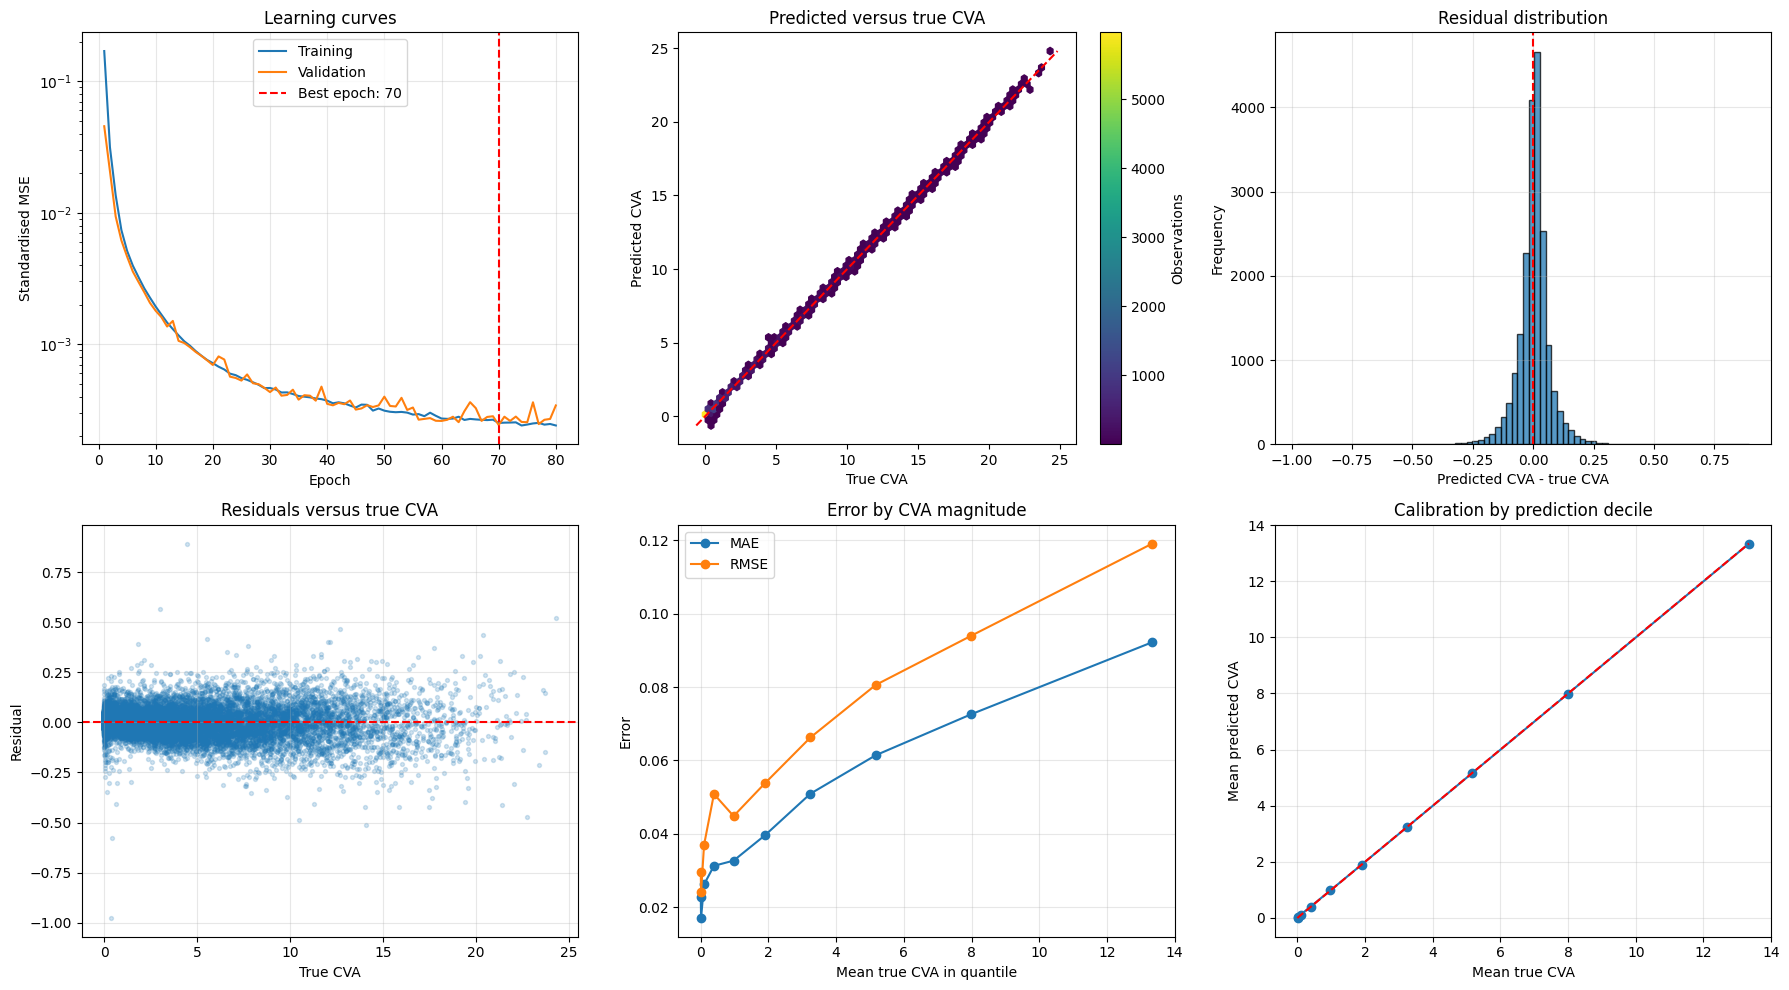

In [9]:
lower = min(y_true.min(), y_pred.min())
upper = max(y_true.max(), y_pred.max())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Learning curves
axes[0, 0].plot(training["epoch"], training["train_loss"], label="Training")

axes[0, 0].plot(training["epoch"], training["validation_loss"], label="Validation")

axes[0, 0].axvline(best_epoch, color="red", linestyle="--", label=f"Best epoch: {best_epoch}")

axes[0, 0].set_yscale("log")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Standardised MSE")
axes[0, 0].set_title("Learning curves")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Predicted versus true
hexbin = axes[0, 1].hexbin(y_true, y_pred, gridsize=60, mincnt=1, cmap="viridis")

axes[0, 1].plot([lower, upper], [lower, upper], color="red", linestyle="--")

axes[0, 1].set_xlabel("True CVA")
axes[0, 1].set_ylabel("Predicted CVA")
axes[0, 1].set_title("Predicted versus true CVA")

fig.colorbar(hexbin, ax=axes[0, 1], label="Observations")

# Residual distribution
axes[0, 2].hist(residuals, bins=80, edgecolor="black", alpha=0.75)

axes[0, 2].axvline(0, color="red", linestyle="--")

axes[0, 2].set_xlabel("Predicted CVA - true CVA")
axes[0, 2].set_ylabel("Frequency")
axes[0, 2].set_title("Residual distribution")
axes[0, 2].grid(alpha=0.3)

# Residuals versus true CVA
axes[1, 0].scatter(y_true, residuals, s=8, alpha=0.2)

axes[1, 0].axhline(0, color="red", linestyle="--")

axes[1, 0].set_xlabel("True CVA")
axes[1, 0].set_ylabel("Residual")
axes[1, 0].set_title("Residuals versus true CVA")
axes[1, 0].grid(alpha=0.3)

# Error by CVA magnitude
axes[1, 1].plot(error_by_cva["mean_true_cva"], error_by_cva["mae"], marker="o", label="MAE")

axes[1, 1].plot(error_by_cva["mean_true_cva"], error_by_cva["rmse"], marker="o", label="RMSE")

axes[1, 1].set_xlabel("Mean true CVA in quantile")
axes[1, 1].set_ylabel("Error")
axes[1, 1].set_title("Error by CVA magnitude")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Calibration
calibration_lower = min(calibration["mean_true_cva"].min(), calibration["mean_predicted_cva"].min())

calibration_upper = max(calibration["mean_true_cva"].max(), calibration["mean_predicted_cva"].max())

axes[1, 2].plot(calibration["mean_true_cva"], calibration["mean_predicted_cva"], marker="o")

axes[1, 2].plot([calibration_lower, calibration_upper], [calibration_lower, calibration_upper], color="red", linestyle="--")

axes[1, 2].set_xlabel("Mean true CVA")
axes[1, 2].set_ylabel("Mean predicted CVA")
axes[1, 2].set_title("Calibration by prediction decile")
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(VALIDATION_PLOTS_PATH, dpi=300, bbox_inches="tight")

plt.show()